# Descriptive Analysis

## General Conclusions
- xx

In [16]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load panel ---
panel_path = f"../../{config['paths']['analysis_panel']}"
panel = pd.read_parquet(panel_path)

print(f"Shape: {panel.shape}")
print(f"Sectors: {sorted(panel['IS8_SECTOR'].unique())}")
print(f"Years: {panel['YEAR'].min()} — {panel['YEAR'].max()}")
print(f"LADs: {panel['GEOGRAPHY_CODE'].nunique()}")
print(f"Columns: {list(panel.columns)}")

Shape: (16576, 35)
Sectors: ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']
Years: 2016 — 2023
LADs: 296
Columns: ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'enterprise_birth_rate', 'enterprise_death_rate', 'enterprise_high_growth_rate', 'REGION', 'COUNTY_UA', 'n_universities_feecap_lad', 'lq_bus', 'emp_share', 'lq_emp', 'gd_emp', 'gd_bus', 'n_years_emp', 'n_years_bus', 'related_variety', 'within_sector_diversity', 'size_large_share', 'size_micro_share']


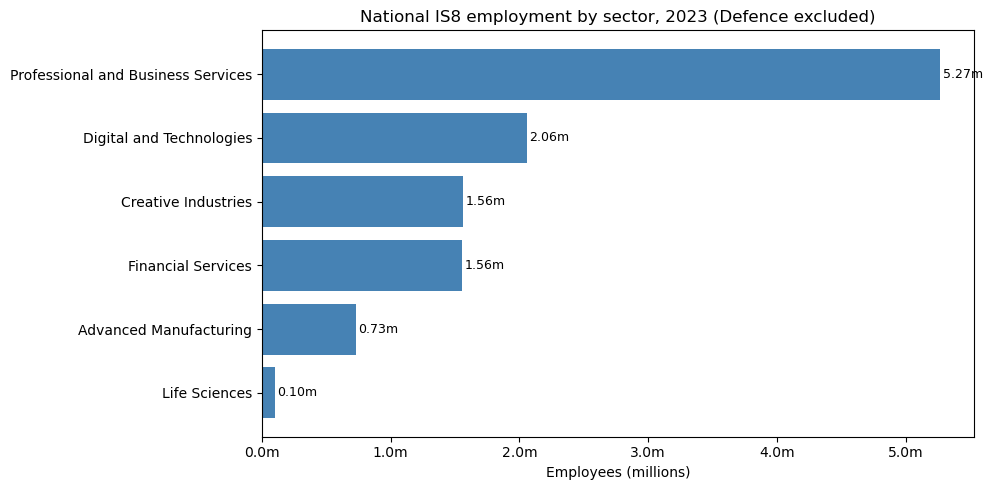

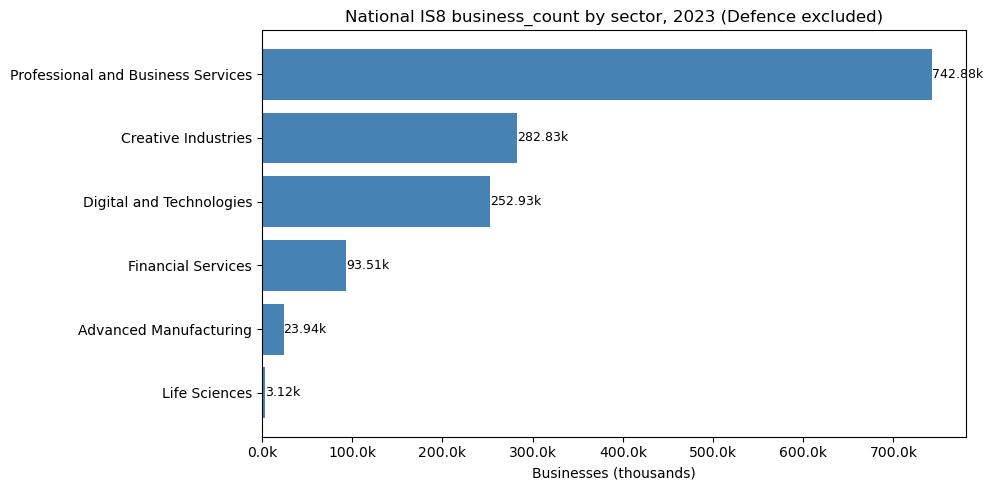

In [22]:
# --- National IS8 employment and business count by sector (most recent year) ---
EXCLUDE_DEFENCE = True

latest_year = panel['YEAR'].max()
plot_data = panel[panel['YEAR'] == latest_year].copy()
if EXCLUDE_DEFENCE:
    plot_data = plot_data[plot_data['IS8_SECTOR'] != 'Defence']

out_path = f"../../{config['paths']['output']}/graphs/Franco"
title_suffix = ' (Defence excluded)' if EXCLUDE_DEFENCE else ''

for metric, col, xlabel, unit, divisor in [
    ('employment', 'EMPLOYEES', 'Employees (millions)', 'm', 1_000_000),
    ('business_count', 'BUSINESSES', 'Businesses (thousands)', 'k', 1_000),
]:
    national = (
        plot_data
        .groupby('IS8_SECTOR')[col]
        .sum()
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(national.index, national.values / divisor, color='steelblue')
    ax.set_xlabel(xlabel)
    ax.set_title(f'National IS8 {metric} by sector, {latest_year}{title_suffix}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}{unit}'))
    for bar, val in zip(bars, national.values):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val/divisor:.2f}{unit}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{out_path}/national_is8_{metric}_{latest_year}.png', dpi=150)
    plt.show()

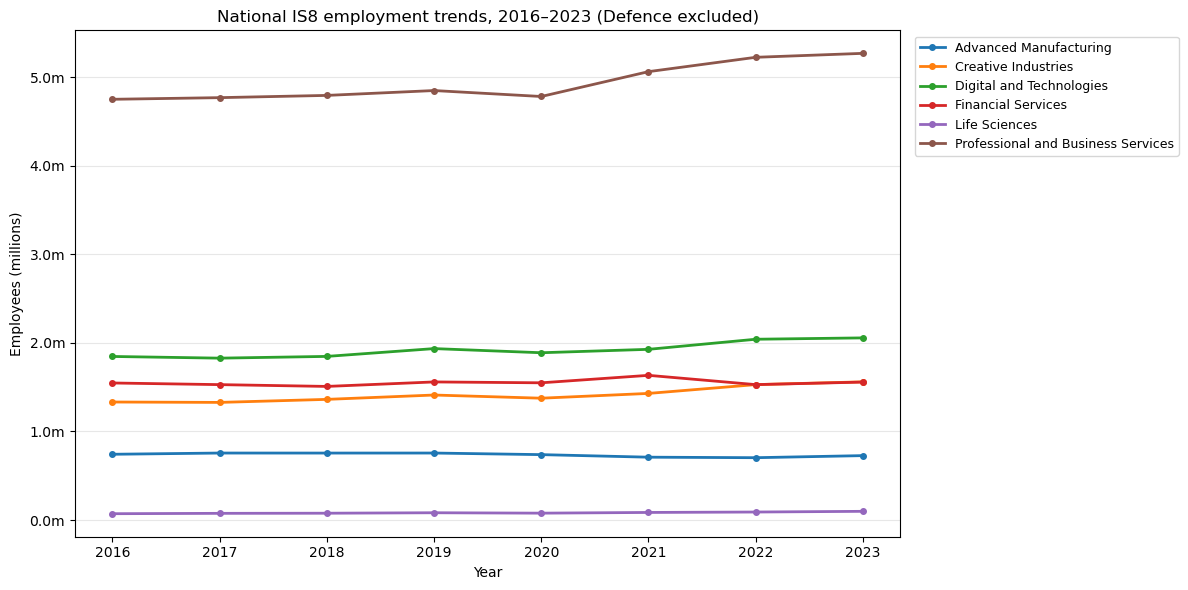

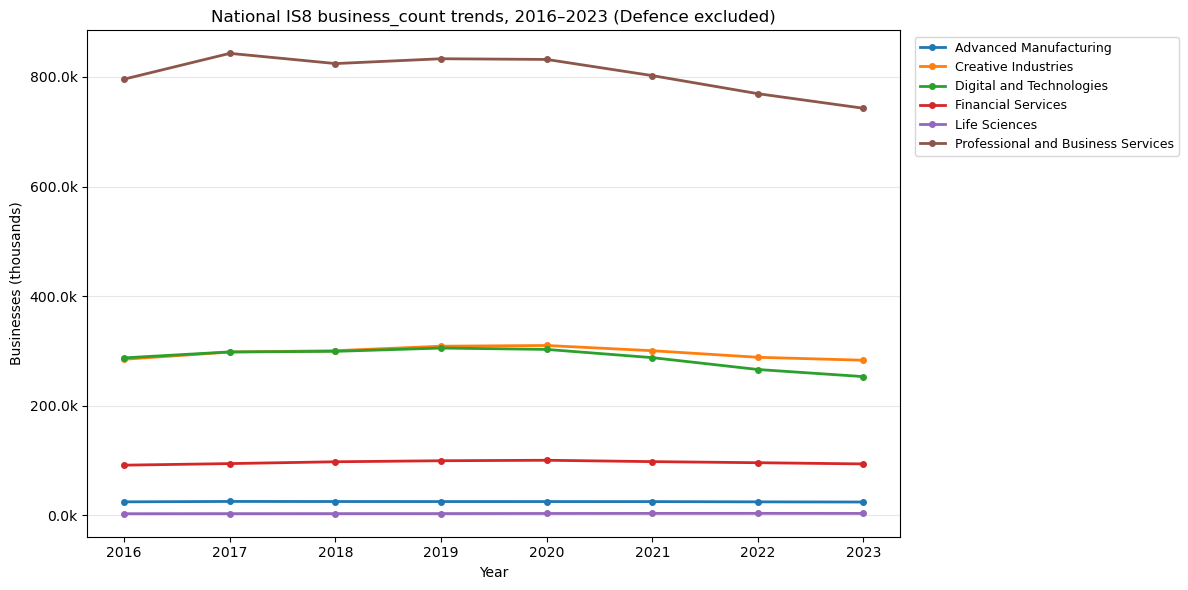

In [21]:
# --- National IS8 employment and business count trends ---
EXCLUDE_DEFENCE = True

plot_data = panel.copy()
if EXCLUDE_DEFENCE:
    plot_data = plot_data[plot_data['IS8_SECTOR'] != 'Defence']

year_min = panel['YEAR'].min()
year_max = panel['YEAR'].max()
sectors = sorted(plot_data['IS8_SECTOR'].unique())
colors = plt.cm.tab10.colors
out_path = f"../../{config['paths']['output']}/graphs/Franco"

for metric, col, ylabel, unit, divisor in [
    ('employment', 'EMPLOYEES', 'Employees (millions)', 'm', 1_000_000),
    ('business_count', 'BUSINESSES', 'Businesses (thousands)', 'k', 1_000),
]:
    trends = (
        plot_data
        .groupby(['YEAR', 'IS8_SECTOR'])[col]
        .sum()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, sector in enumerate(sectors):
        data = trends[trends['IS8_SECTOR'] == sector].sort_values('YEAR')
        ax.plot(data['YEAR'], data[col] / divisor,
                label=sector, color=colors[i], linewidth=2, marker='o', markersize=4)

    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    title_suffix = ' (Defence excluded)' if EXCLUDE_DEFENCE else ''
    ax.set_title(f'National IS8 {metric} trends, {year_min}–{year_max}{title_suffix}')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}{unit}'))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{out_path}/national_is8_{metric}_trends_{year_min}_{year_max}.png', dpi=150, bbox_inches='tight')
    plt.show()

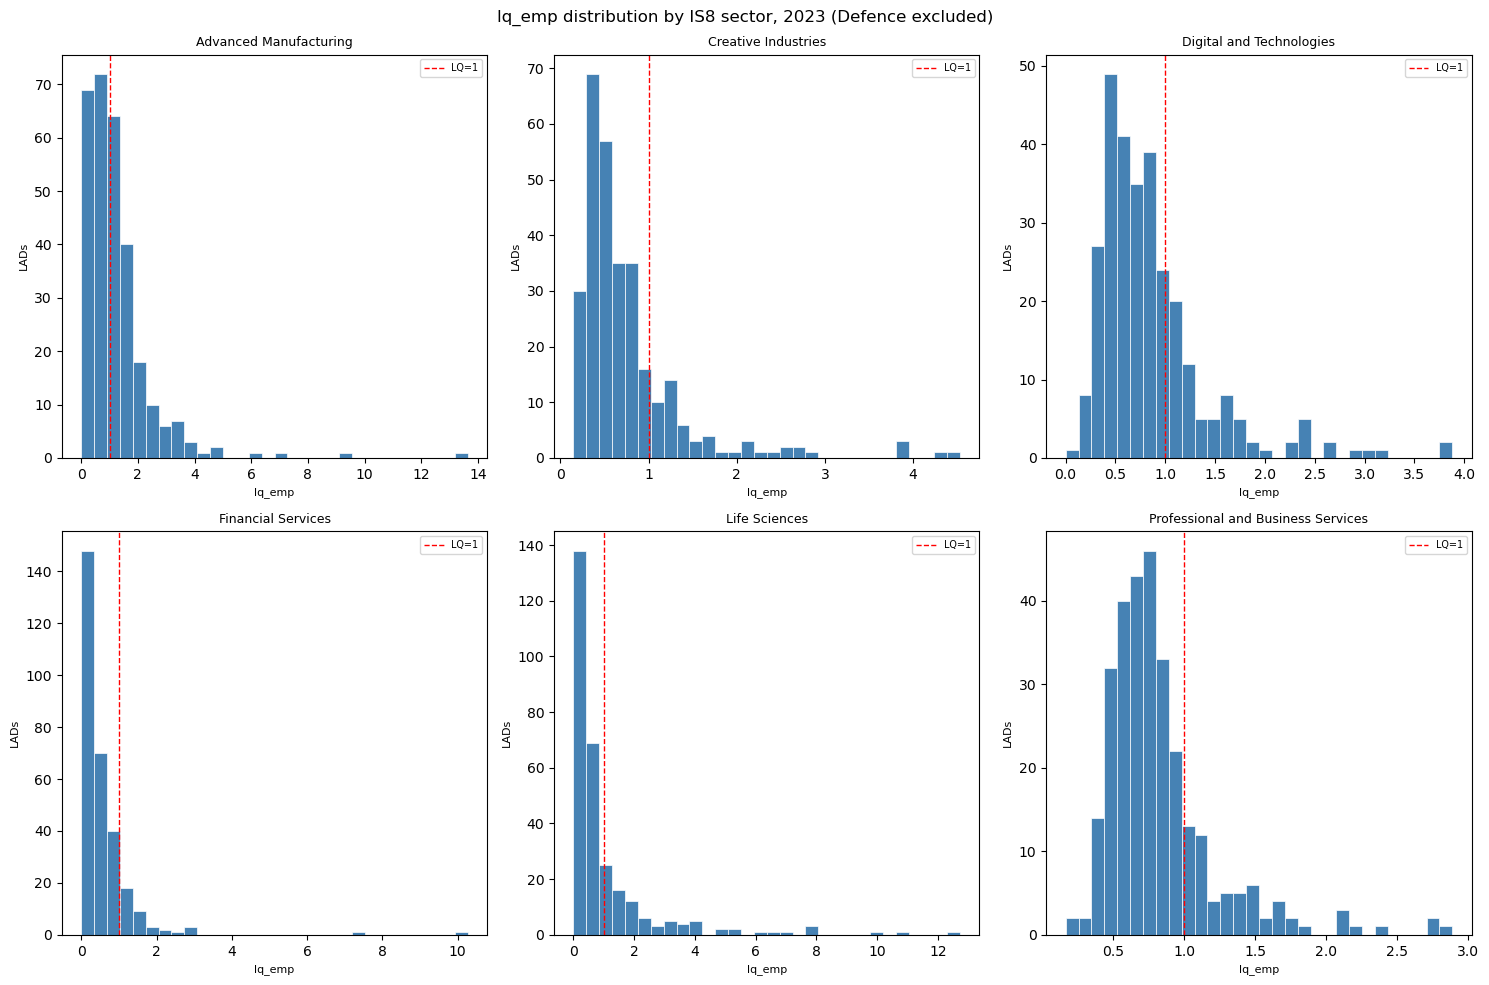

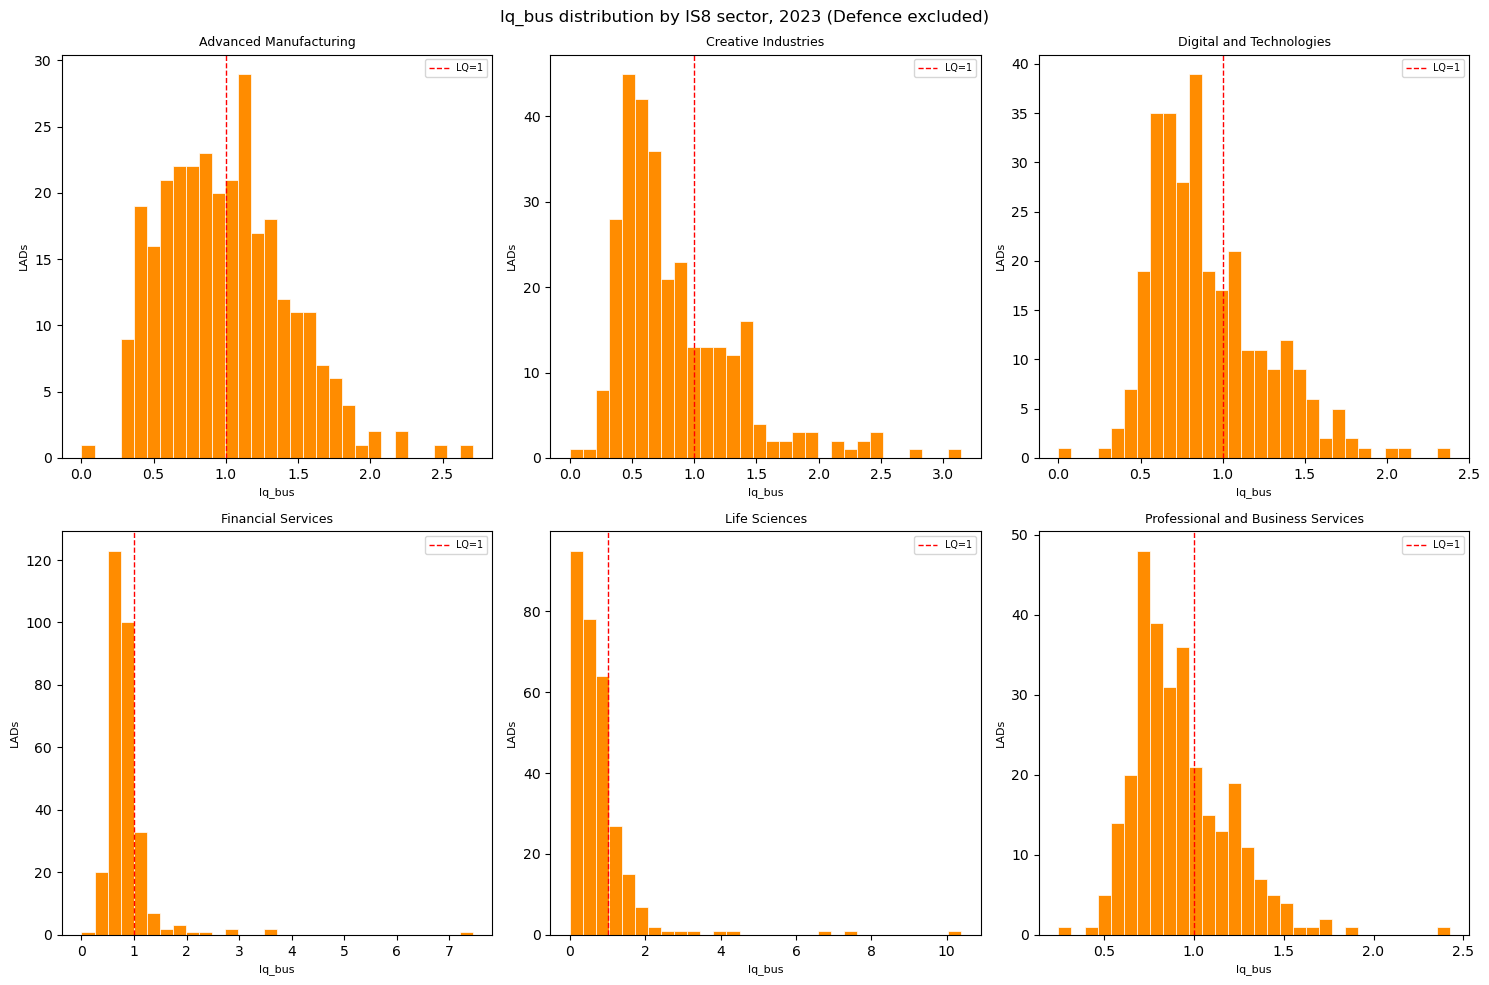

In [23]:
# --- LQ distribution by IS8 sector (most recent year) ---
EXCLUDE_DEFENCE = True

latest_year = panel['YEAR'].max()
plot_data = panel[panel['YEAR'] == latest_year].copy()
if EXCLUDE_DEFENCE:
    plot_data = plot_data[plot_data['IS8_SECTOR'] != 'Defence']

sectors = sorted(plot_data['IS8_SECTOR'].unique())
out_path = f"../../{config['paths']['output']}/graphs/Franco"
title_suffix = ' (Defence excluded)' if EXCLUDE_DEFENCE else ''
n_cols = 3
n_rows = int(np.ceil(len(sectors) / n_cols))

for y_var, color in [('lq_emp', 'steelblue'), ('lq_bus', 'darkorange')]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, sector in enumerate(sectors):
        data = plot_data[plot_data['IS8_SECTOR'] == sector][y_var].dropna()
        axes[i].hist(data, bins=30, color=color, edgecolor='white', linewidth=0.5)
        axes[i].axvline(x=1, color='red', linestyle='--', linewidth=1, label='LQ=1')
        axes[i].set_title(sector, fontsize=9)
        axes[i].set_xlabel(y_var, fontsize=8)
        axes[i].set_ylabel('LADs', fontsize=8)
        axes[i].legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{y_var} distribution by IS8 sector, {latest_year}{title_suffix}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{out_path}/{y_var}_distribution_{latest_year}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [25]:
from src.regions import RegionMapper

mapper = RegionMapper(config, panel)
mapper.verify()

[RegionMapper] WARNING — Glasgow City Region: LADs not found in panel: ['Glasgow City', 'East Dunbartonshire', 'West Dunbartonshire', 'North Lanarkshire', 'South Lanarkshire', 'East Renfrewshire', 'Renfrewshire', 'Inverclyde']
[RegionMapper] WARNING — Cardiff-Newport: LADs not found in panel: ['Cardiff', 'Newport']
[RegionMapper] WARNING — Edinburgh City Region: LADs not found in panel: ['City of Edinburgh', 'East Lothian', 'Midlothian', 'West Lothian']
South Yorkshire MCA (4 LADs): ['Barnsley', 'Doncaster', 'Rotherham', 'Sheffield']
West Midlands CA (7 LADs): ['Birmingham', 'Coventry', 'Dudley', 'Sandwell', 'Solihull', 'Walsall', 'Wolverhampton']
West Yorkshire CA (5 LADs): ['Bradford', 'Calderdale', 'Kirklees', 'Leeds', 'Wakefield']
Greater Manchester CA (10 LADs): ['Bolton', 'Bury', 'Manchester', 'Oldham', 'Rochdale', 'Salford', 'Stockport', 'Tameside', 'Trafford', 'Wigan']
West of England CA (3 LADs): ['Bath and North East Somerset', 'Bristol, City of', 'South Gloucestershire']
Liv